# Wine Veri Seti ile Sınıflandırma Analizi

## Proje Özeti
Bu çalışmada, scikit-learn kütüphanesinde yer alan **Wine veri seti** kullanılarak sınıflandırma işlemi gerçekleştirilmiştir. Amaç, şarap örneklerini özelliklerine göre doğru sınıfa ayırabilen modelleri incelemek ve performanslarını karşılaştırmaktır.

## Veri Seti Hakkında
Wine veri seti, farklı kimyasal özelliklere sahip şarap örneklerinden oluşmaktadır. Veri setinde toplam **178 gözlem**, **13 bağımsız değişken** ve **3 farklı sınıf** bulunmaktadır.

## Hedef Değişken
Tahmin edilmek istenen değişken: **class**

## Uygulanan Adımlar
1. Veri seti yüklendi  
2. Bağımsız ve bağımlı değişkenler ayrıldı  
3. Eğitim ve test verileri oluşturuldu  
4. Karar Ağacı modeli kuruldu  
5. KNN modeli kuruldu  
6. Modeller karşılaştırıldı  

## Sonuç
Karşılaştırma sonucunda **Karar Ağacı modelinin**, bu veri setinde **KNN modeline göre daha başarılı** olduğu görülmüştür.

In [ ]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()

data = pd.DataFrame(wine.data, columns=wine.feature_names)
data["class"] = wine.target

data

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [ ]:
X = data.drop("class", axis=1)
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [ ]:
y = data["class"]
y

,class
0,0
1,0
2,0
3,0
4,0
...,...
173,2
174,2
175,2
176,2


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42
)

In [ ]:
X_train

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
22,13.71,1.86,2.36,16.6,101.0,2.61,2.88,0.27,1.69,3.80,1.11,4.00,1035.0
146,13.88,5.04,2.23,20.0,80.0,0.98,0.34,0.40,0.68,4.90,0.58,1.33,415.0
97,12.29,1.41,1.98,16.0,85.0,2.55,2.50,0.29,1.77,2.90,1.23,2.74,428.0
69,12.21,1.19,1.75,16.8,151.0,1.85,1.28,0.14,2.50,2.85,1.28,3.07,718.0
167,12.82,3.37,2.30,19.5,88.0,1.48,0.66,0.40,0.97,10.26,0.72,1.75,685.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,13.86,1.51,2.67,25.0,86.0,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410.0
106,12.25,1.73,2.12,19.0,80.0,1.65,2.03,0.37,1.63,3.40,1.00,3.17,510.0
14,14.38,1.87,2.38,12.0,102.0,3.30,3.64,0.29,2.96,7.50,1.20,3.00,1547.0
92,12.69,1.53,2.26,20.7,80.0,1.38,1.46,0.58,1.62,3.05,0.96,2.06,495.0


In [ ]:
X_test

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
19,13.64,3.10,2.56,15.2,116.0,2.70,3.03,0.17,1.66,5.100000,0.96,3.36,845.0
45,14.21,4.04,2.44,18.9,111.0,2.85,2.65,0.30,1.25,5.240000,0.87,3.33,1080.0
140,12.93,2.81,2.70,21.0,96.0,1.54,0.50,0.53,0.75,4.600000,0.77,2.31,600.0
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.700000,1.19,2.71,1285.0
67,12.37,1.17,1.92,19.6,78.0,2.11,2.00,0.27,1.04,4.680000,1.12,3.48,510.0
16,14.30,1.92,2.72,20.0,120.0,2.80,3.14,0.33,1.97,6.200000,1.07,2.65,1280.0
119,12.00,3.43,2.00,19.0,87.0,2.00,1.64,0.37,1.87,1.280000,0.93,3.05,564.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.300000,0.70,1.56,750.0
109,11.61,1.35,2.70,20.0,94.0,2.74,2.92,0.29,2.49,2.650000,0.96,3.26,680.0
141,13.36,2.56,2.35,20.0,89.0,1.40,0.50,0.37,0.64,5.600000,0.70,2.47,780.0


In [ ]:
from sklearn.tree import DecisionTreeClassifier

KA = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=0)

KA.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [ ]:
tahmin = KA.predict(X_test)
tahmin

array([0, 0, 1, 0, 1, 0, 1, 2, 1, 0, 0, 2, 0, 2, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0, 1, 2, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 2, 0, 1, 0, 0, 1, 2, 1, 1, 0, 1])

In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, tahmin))

0.8813559322033898


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, tahmin)
print(cm)

[[20  0  0]
 [ 0 23  1]
 [ 1  5  9]]


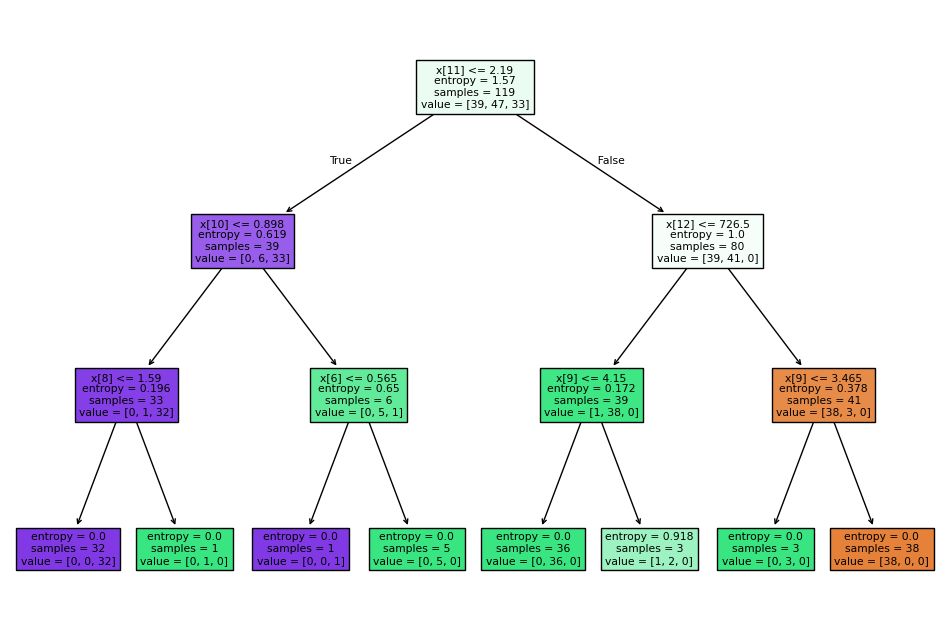

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(12,8))
tree.plot_tree(KA, filled=True)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, tahmin))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       0.82      0.96      0.88        24
           2       0.90      0.60      0.72        15

    accuracy                           0.88        59
   macro avg       0.89      0.85      0.86        59
weighted avg       0.89      0.88      0.87        59



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

classifier2 = KNeighborsClassifier(n_neighbors=5)

classifier2.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
tahmin_knn = classifier2.predict(X_test)

tahmin_knn

array([2, 0, 1, 0, 1, 0, 1, 2, 2, 0, 2, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       2, 1, 1, 1, 1, 2, 1, 0, 0, 1, 2, 0, 0, 0, 2, 2, 2, 1, 0, 1, 1, 0,
       1, 0, 2, 1, 2, 0, 1, 0, 0, 2, 1, 2, 0, 1, 1])

In [ ]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, tahmin_knn))

0.6779661016949152


In [ ]:
from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(y_test, tahmin_knn)
print(cm_knn)
from sklearn.metrics import classification_report

print(classification_report(y_test, tahmin_knn))

[[17  1  2]
 [ 2 16  6]
 [ 1  7  7]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        20
           1       0.67      0.67      0.67        24
           2       0.47      0.47      0.47        15

    accuracy                           0.68        59
   macro avg       0.66      0.66      0.66        59
weighted avg       0.68      0.68      0.68        59



In [ ]:
karar_agaci_acc = accuracy_score(y_test, tahmin)
knn_acc = accuracy_score(y_test, tahmin_knn)

print("Karar Ağacı Accuracy:", karar_agaci_acc)
print("KNN Accuracy:", knn_acc)

if karar_agaci_acc > knn_acc:
    print("Sonuç: Karar Ağacı modeli daha başarılıdır.")
elif knn_acc > karar_agaci_acc:
    print("Sonuç: KNN modeli daha başarılıdır.")
else:
    print("Sonuç: İki modelin başarısı eşittir.")

Karar Ağacı Accuracy: 0.8813559322033898
KNN Accuracy: 0.6779661016949152
Sonuç: Karar Ağacı modeli daha başarılıdır.
